# Quantitative Portfolio Optimization & Risk Analysis

## 1. Project Goal

In this project, we apply quantitative finance techniques in order to construct and analyze a stock portfolio.

The goal is to investigate the relationship between risk and return using logarithmic returns, volatility, correlation matrices, covariance matrices, Monte Carlo simulation, and portfolio optimization techniques.

More specifically, having fixed the assets composing our portfolio, we aim to identify the optimal weights in order to achieve an efficient trade-off between expected return and risk, based on the principles of Modern Portfolio Theory.

## 2. Ipmorting Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.optimize import minimize

## 3. Data Collection

We collect historical stock data for companies from different market sectors:  technology, healthcare, financials, consumer staples, and energy. 

In this way, one can better examine the effects of diversification and correlation on portfolio risk and performance.

In addition to our portfolio stocks, we include the S&P 500 index as a benchmark representing the overall market. We shall compare the portfolio's performance with that of the index.

In [4]:
stocks = ['AAPL', 'MSFT', 'JNJ', 'JPM', 'KO', 'XOM']

benckmark = '^GSPC'

In [5]:
data = yf.download(stocks, start='2020-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Date,,,,,,
2020-01-02,72.333870,122.638214,118.430305,45.432709,151.829559,52.947029
2020-01-03,71.630661,121.218346,116.867462,45.184841,149.939011,52.521358
2020-01-06,72.201408,121.067131,116.774529,45.168324,150.326538,52.924633
2020-01-07,71.861855,121.806465,114.789299,44.821323,148.955902,52.491493
2020-01-08,73.017815,121.789688,115.684799,44.903950,151.328537,51.699905


In [6]:
benchmark_data = yf.download(benckmark, start='2020-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

benchmark_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


**Remark:** Throughout this project we use adjusted closing prices, due to their providing a more accurate representation of asset values.

**Remark:** The selected time period (2020-2025) is particularly interesting, because it includes several events which significantly influenced market performance, such as COVID-19 and its consequences.

Moreover, the five-year time horizon provides a sufficient number of observations for our statistical analysis. 

# 4. Data Inspection & Cleaning

Before proceeding with the analysis, we inspect the structure and quality of our datasets.

In [7]:
data.shape

(1258, 6)

In [8]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   JNJ     1258 non-null   float64
 2   JPM     1258 non-null   float64
 3   KO      1258 non-null   float64
 4   MSFT    1258 non-null   float64
 5   XOM     1258 non-null   float64
dtypes: float64(6)
memory usage: 68.8 KB


In [9]:
data.isnull().sum()

Ticker
AAPL    0
JNJ     0
JPM     0
KO      0
MSFT    0
XOM     0
dtype: int64

In [10]:
data.describe()

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,151.377786,143.684102,135.491524,51.910027,285.724092,73.433010
std,41.851998,11.824775,37.831734,7.368285,81.058642,28.858525
min,54.163704,93.970856,66.763306,31.304205,128.358368,23.823557
25%,126.279119,138.840351,109.972448,46.773105,226.536335,46.591511
50%,149.968620,145.948975,132.128441,53.756039,273.605850,79.235241
75%,175.902031,151.726978,147.840569,56.735517,330.229858,99.136545
max,257.375549,165.628784,242.758469,69.427246,460.325592,118.348557


The descriptive statistics provide an initial overview of the price levels and variability of the selected assets over the examined period.

We now perform the same inspection process for the benchmark dataset.

In [11]:
benchmark_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^GSPC   1258 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB


In [12]:
benchmark_data.isnull().sum()

Ticker
^GSPC    0
dtype: int64

**Remark:** Both datasets contain no missing values.

# 5. Exploratory Price Analysis

In this section, we examine the evolution of both the portfolio asset prices and the benchmark index over time.

We begin with the portfolio assets.

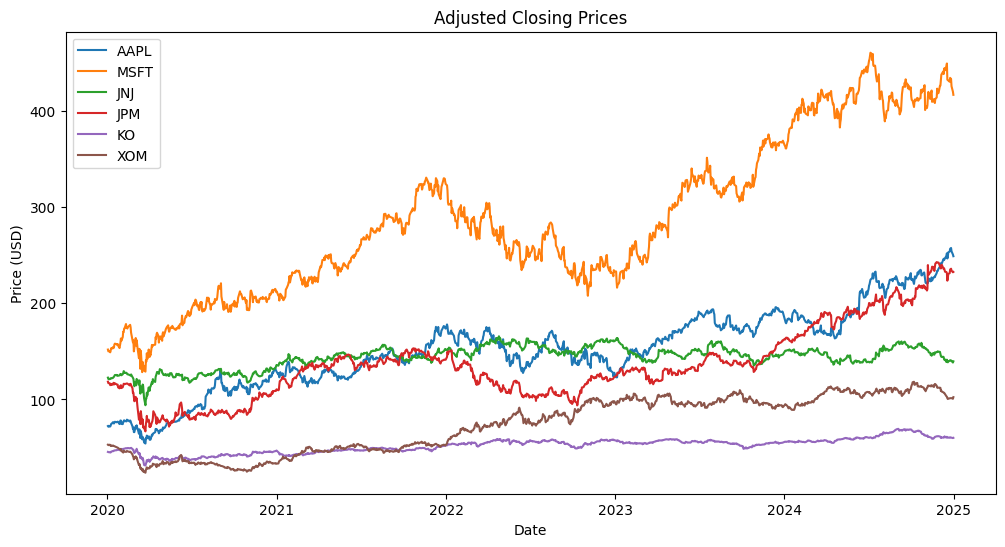

In [13]:
plt.figure(figsize=(12,6))

for stock in stocks:
    
    plt.plot(data[stock], label=stock)

plt.title('Adjusted Closing Prices')

plt.xlabel('Date')

plt.ylabel('Price (USD)')

plt.legend()

plt.show()

**Remark:** All assets exhibit an overall upward trend. However, noticeable differences in growth rate and volatility can still be observed.

Next, we examine the S&P 500 graph, which represents the overall market behavior.

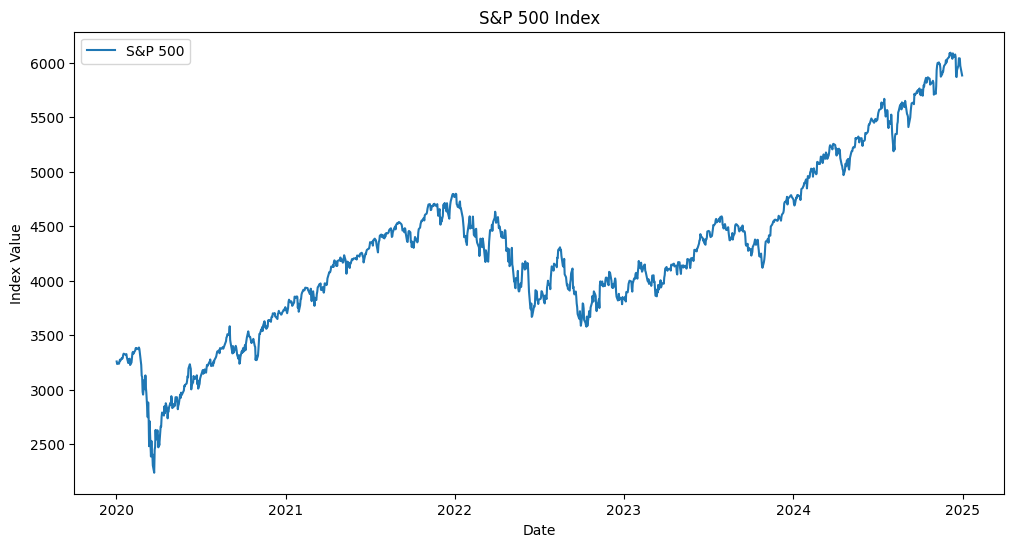

In [14]:
plt.figure(figsize=(12,6))

plt.plot(benchmark_data, label='S&P 500')

plt.title('S&P 500 Index')

plt.xlabel('Date')

plt.ylabel('Index Value')

plt.legend()

plt.show()

**Remark:** This graph also demonstrates an overall upward trend accompanied by significant fluctuations. More precisely, a notable decline can be observed during early 2020, mainly due to COVID-19 and the resulting economic uncertainty. Nevertheless, this period was followed by a strong market recovery in the following years.

Since the assets are on different price scales, we normalize all price series dividing each one by its very first value. This makes the data more suitable for comparison.

In [15]:
normalized_data = data / data.iloc[0]

normalized_benchmark = benchmark_data / benchmark_data.iloc[0]

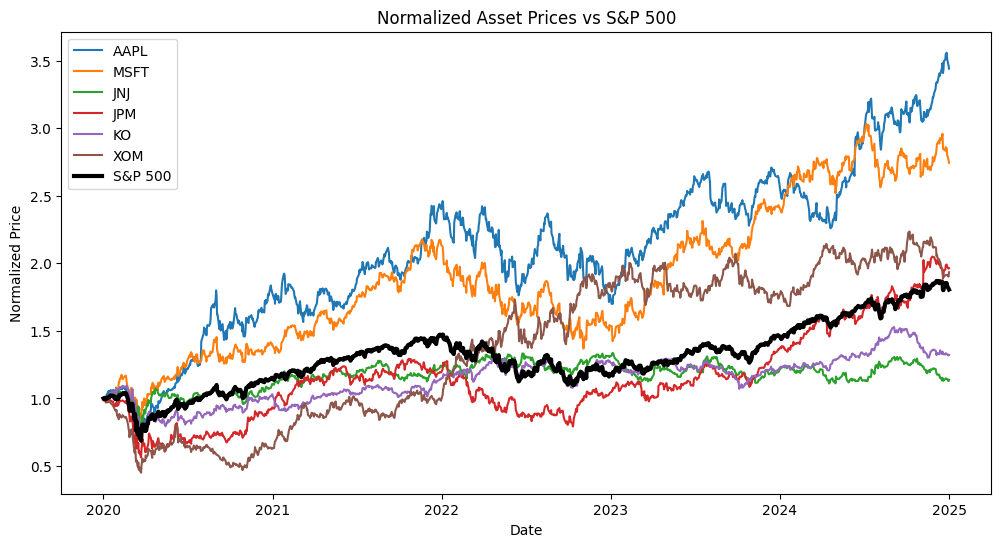

In [16]:
plt.figure(figsize=(12,6))

for stock in stocks:
    
    plt.plot(normalized_data[stock], label=stock)

plt.plot(normalized_benchmark, label='S&P 500', linewidth=3, color='black')

plt.title('Normalized Asset Prices vs S&P 500')

plt.xlabel('Date')

plt.ylabel('Normalized Price')

plt.legend()

plt.show()

**Remark:** Comparing the line plots, one can identify the assets which outperformed or underperformed relative to the S&P 500.

## 6. Log Returns Analysis

We now compute the logarithmic returns of the portfolio assets and the benchmark.

In [17]:
log_returns = np.log(data / data.shift(1))

log_returns.head()

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009769,-0.011645,-0.013284,-0.005471,-0.012530,-0.008072
2020-01-06,0.007936,-0.001248,-0.000796,-0.000366,0.002581,0.007649
2020-01-07,-0.004714,0.006088,-0.017147,-0.007712,-0.009160,-0.008218
2020-01-08,0.015958,-0.000138,0.007771,0.001842,0.015803,-0.015195


In [18]:
benchmark_log_returns = np.log(benchmark_data / benchmark_data.shift(1))

benchmark_log_returns.head()

Ticker,^GSPC
Date,
2020-01-02,NaN
2020-01-03,-0.007085
2020-01-06,0.003527
2020-01-07,-0.002807
2020-01-08,0.004890


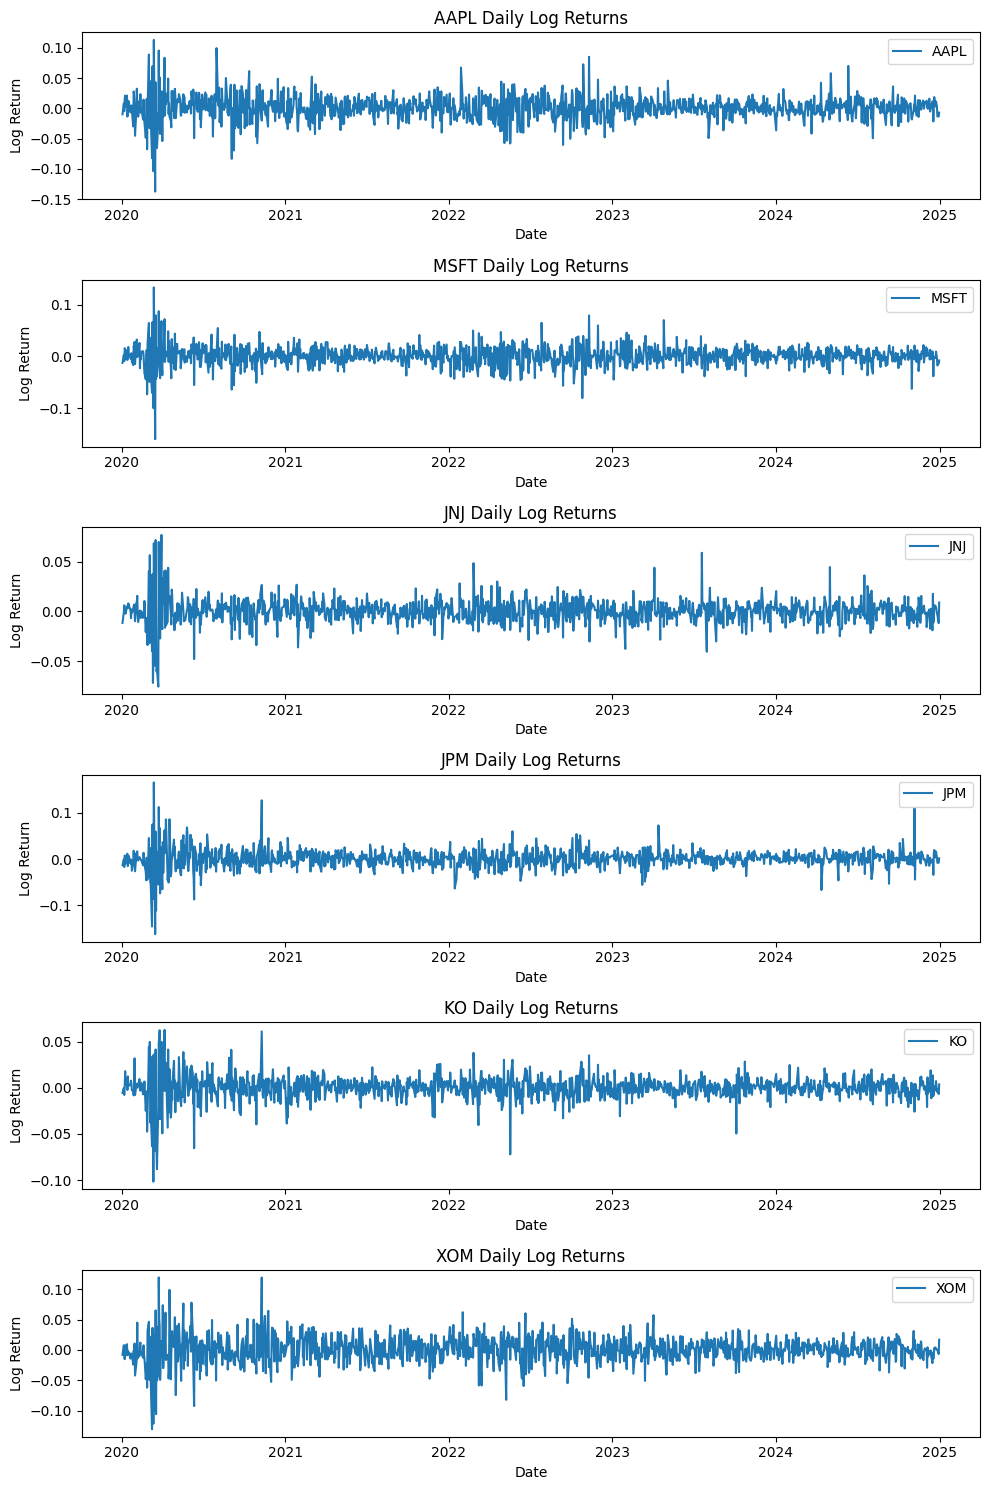

In [19]:
plt.figure(figsize=(10,15))

for stock in stocks:
    
    plt.subplot(len(stocks), 1, stocks.index(stock)+1)
    
    plt.plot(log_returns[stock], label=stock)
    
    plt.title(str(stock) + ' Daily Log Returns')
    
    plt.xlabel('Date')
    
    plt.ylabel('Log Return')
    
    plt.legend()

plt.tight_layout()

plt.show()

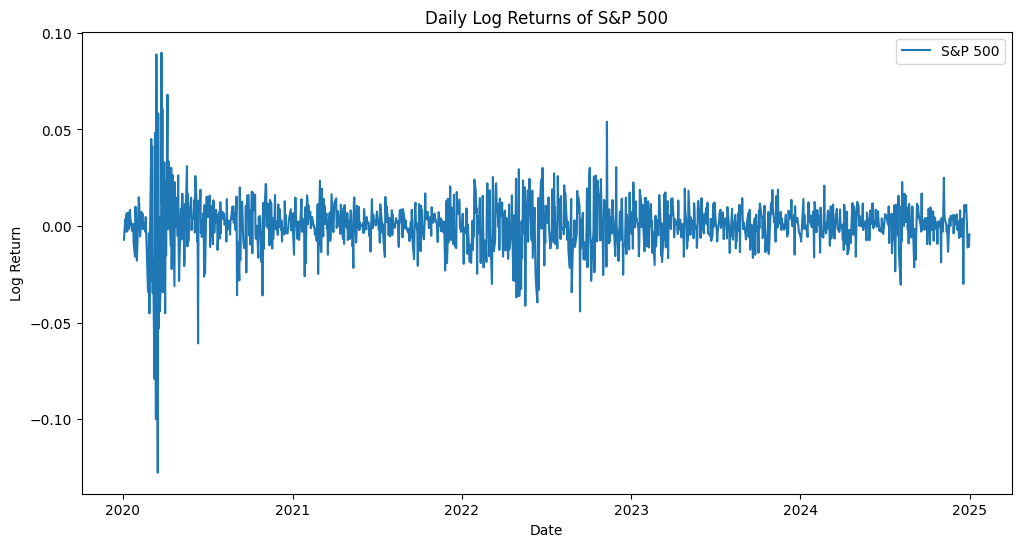

In [20]:
plt.figure(figsize=(12,6))

plt.plot(benchmark_log_returns, label='S&P 500')

plt.title('Daily Log Returns of S&P 500')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

**Remark:** Both the portfolio asset returns and S&P 500 log returns fluctuate around zero and exhibit periods of increased volatility, especially during market stress periods.

Below, we calculate and visualize the annualized mean returns and volatility (always using log returns).

Before proceeding though, note that for an asset $X$ with log returns $X_1, X_2, \dots, X_n$, the (daily) mean and standard deviation are given by the following formulas, respectively:
$$\bar{X} = \frac{1}{n}\sum\limits_{i=1}^{n}X_i$$

$$\sigma (X) = \sqrt{\frac{1}{n-1}\sum\limits_{i=1}^{n}(X_i - \bar{X})^2}.$$

To annualize, one simply has to multiply $\bar{X}$ by the number of trading days in a year, namely 252, and $\sigma(X)$ by $\sqrt{252}$.

In [21]:
annual_mean_returns = log_returns.mean() * 252

annual_mean_returns

Ticker
AAPL    0.247685
JNJ     0.025945
JPM     0.135232
KO      0.055965
MSFT    0.202335
XOM     0.132194
dtype: float64

In [22]:
for stock in stocks:
    print(f'{stock:<4}| Annualized Mean Return: {round(annual_mean_returns[stock] * 100, 2)}%')

AAPL| Annualized Mean Return: 24.77%
MSFT| Annualized Mean Return: 20.23%
JNJ | Annualized Mean Return: 2.59%
JPM | Annualized Mean Return: 13.52%
KO  | Annualized Mean Return: 5.6%
XOM | Annualized Mean Return: 13.22%


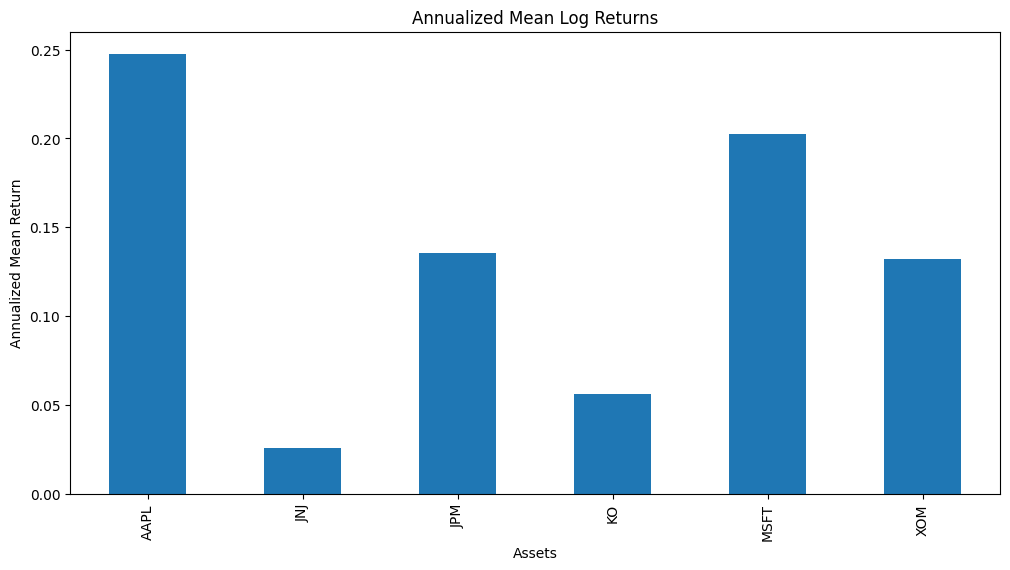

In [23]:
plt.figure(figsize=(12,6))

annual_mean_returns.plot(kind='bar')

plt.title('Annualized Mean Log Returns')

plt.xlabel('Assets')

plt.ylabel('Annualized Mean Return')

plt.show()


In [24]:
annual_volatility = log_returns.std() * np.sqrt(252)

annual_volatility

Ticker
AAPL    0.316540
JNJ     0.196151
JPM     0.324487
KO      0.209010
MSFT    0.305233
XOM     0.343887
dtype: float64

In [68]:
for stock in stocks:
    print(f'{stock:<4}| Annualized Volatility: {round(annual_volatility[stock] * 100, 2)}%')

AAPL| Annualized Volatility: 31.65%
MSFT| Annualized Volatility: 30.52%
JNJ | Annualized Volatility: 19.62%
JPM | Annualized Volatility: 32.45%
KO  | Annualized Volatility: 20.9%
XOM | Annualized Volatility: 34.39%


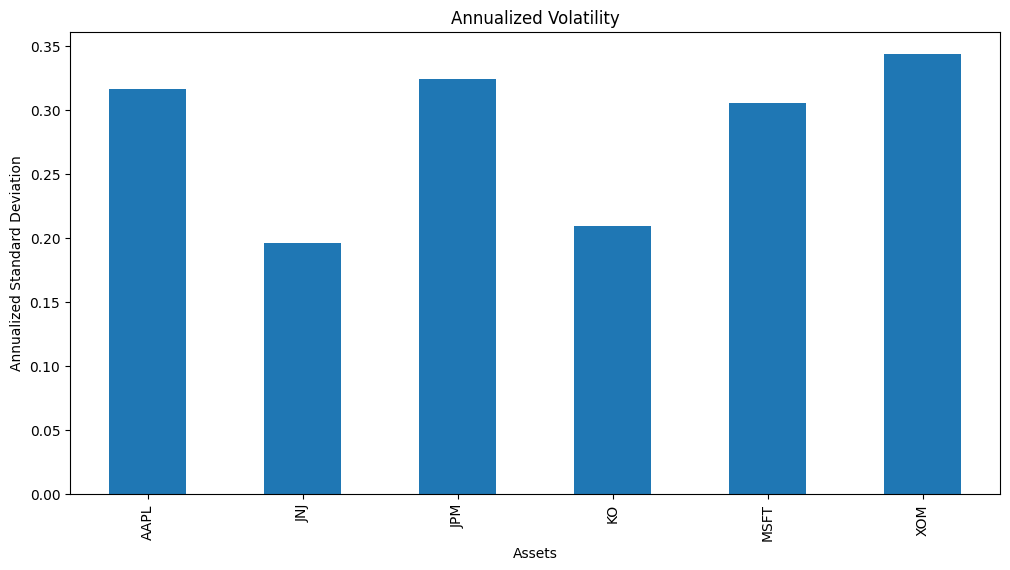

In [26]:
plt.figure(figsize=(12,6))

annual_volatility.plot(kind='bar')

plt.title('Annualized Volatility')

plt.xlabel('Assets')

plt.ylabel('Annualized Standard Deviation')

plt.show()

## 7. Correlation & Covariance Analysis

It is very important to examine the correlation, if any, between the portfolio assets, since portfolio risk depends not only on the volatility of each asset individually, but also on the way the assets interact with one another

Nevertheless, let us discuss some elementary but useful theory first. Suppose we have two assets $X$ and $Y$, with log returns $X_1, X_2, \dots, X_n$ and $Y_1, Y_2, \dots, Y_n$, and daily log return means $\bar{X}$ and $\bar{Y}$, respectively. We define the covariance ($\operatorname{Cov}$) and correlation coefficient ($\rho$) of these assets as follows:

$$\operatorname{Cov}(X, Y) = \frac{1}{n-1}\sum\limits_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})$$

$$\rho (X, Y) = \frac{\operatorname{Cov}(X, Y)}{\sigma(X) \sigma(Y)}.$$

To gain some intuition, covariance measures the tendency of two assets to move together. More precisely, positive covariance implies that the assets tend to move in the same direction, whereas negative covariance implies the opposite. Zero covariance indicates that the assets are uncorrelated.

In addition, $\rho$ is standardized, lying in $[-1, 1].$  Positive $\rho$ implies that the assets tend to move together and the closer $\rho$ to $1$, the stronger the relation between them. Similarly, values close to $-1$ indicate a strong negative correlation.

In [27]:
correlation_matrix = log_returns.corr()

correlation_matrix

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Ticker,,,,,,
AAPL,1.000000,0.374920,0.414321,0.444122,0.750914,0.288141
JNJ,0.374920,1.000000,0.410874,0.589864,0.376939,0.301351
JPM,0.414321,0.410874,1.000000,0.532933,0.424329,0.572315
KO,0.444122,0.589864,0.532933,1.000000,0.436774,0.431263
MSFT,0.750914,0.376939,0.424329,0.436774,1.000000,0.248586
XOM,0.288141,0.301351,0.572315,0.431263,0.248586,1.000000


**Remark:** The element $(i, j)$ of the above matrix, equals the correlation coefficient between the assets in positions $i$ and $j$. Obviously, the diagonal elements equal 1.

The correlation matrix can be visualized using the following heatmap.

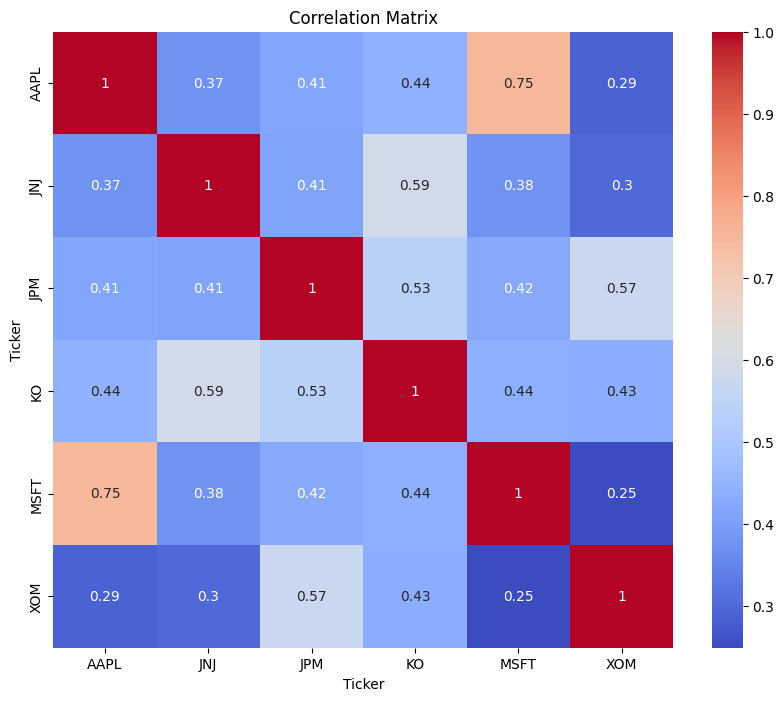

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

**Remark:** Every pair of assets exhibits positive correlations, implying that the assets tend to move in the same direction under normal market conditions. Nevertheless, the correlations are not perfect, allowing for diversification effects within the portfolio.

We continue with the portfolio covariance matrix.

In [29]:
covariance_matrix = log_returns.cov()

covariance_matrix

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Ticker,,,,,,
AAPL,0.000398,0.000092,0.000169,0.000117,0.000288,0.000124
JNJ,0.000092,0.000153,0.000104,0.000096,0.000090,0.000081
JPM,0.000169,0.000104,0.000418,0.000143,0.000167,0.000253
KO,0.000117,0.000096,0.000143,0.000173,0.000111,0.000123
MSFT,0.000288,0.000090,0.000167,0.000111,0.000370,0.000104
XOM,0.000124,0.000081,0.000253,0.000123,0.000104,0.000469


**Remark:** The element $(i, j)$ of the above matrix, equals the covariance between the assets in positions $i$ and $j$. Obviously, the diagonal elements equal the corresponding variance.

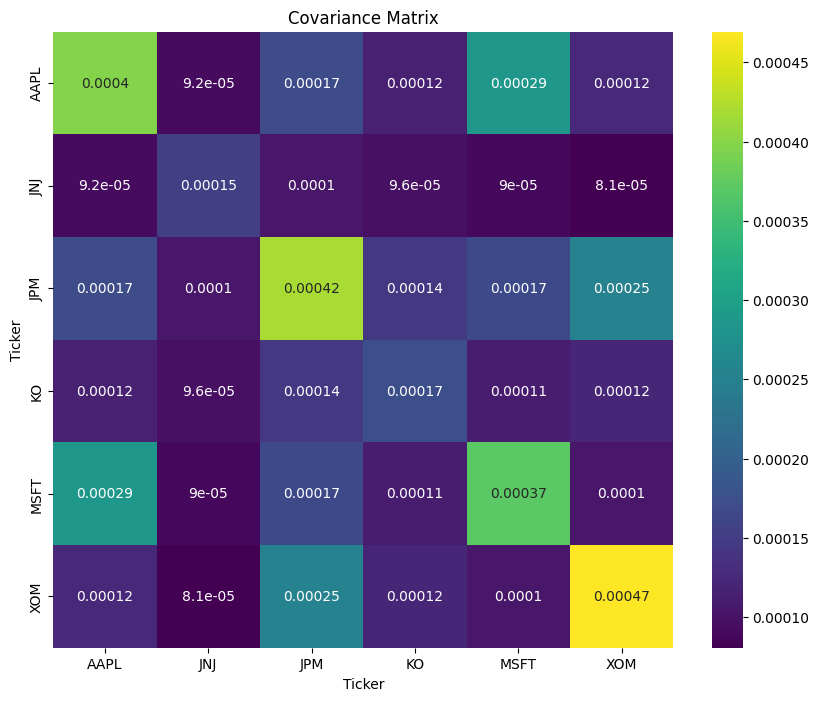

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(covariance_matrix, annot=True, cmap='viridis')

plt.title('Covariance Matrix')

plt.show()

## 8. Portfolio Return, Volatility and Sharpe Rtio

We now study the expected return and volatility of a portfolio consisting of the selected assets.

Suppose the portfolio weights are $w_1, w_2, \dots, w_n,$
where $w_i$ denotes the proportion of capital invested in asset $i.$

Naturally, the weights satisfy
$$\sum\limits_{i=1}^{n}w_i = 1.$$

If $\mu_1, \mu_2, \dots, \mu_n$ denote the annualized mean returns of the assets, then by the linearity of the expected value, the expected portfolio return is defined as follows:
$$\mu_{p} = \sum\limits_{i=1}^{n}w_i\mu _i.$$



Now let's be more precise regarding some elementary probabilistic concepts. 

For two random variables $X_1$, $X_2$ and real numbers $w_1$, $w_2$, it holds

$$\sigma^2(w_1X_1+w_2X_2)=w_1^2\sigma^2(X_1)+w_2^2\sigma^2(X_2)+2w_1w_2\operatorname{Cov}(X_1,X_2).$$

One can easily generalize the above formula for more than two objects:

$$\sigma^2(\sum\limits_{i=1}^{n}w_iX_i) = \sum\limits_{i=1}^{n}\sum\limits_{j=1}^{n}w_iw_j\operatorname{Cov}(X_i, X_j).$$

Thus, the portfolio volatility is given by

$$\sigma_{p} = \sqrt{\sum\limits_{i=1}^{n}\sum\limits_{j=1}^{n}w_iw_j\operatorname{Cov}(X_i, X_j)},$$

which can be written more elegantly as follows:

$$\sigma_{p} = \sqrt{w^T\Sigma w},$$

where $w = (w_1, w_2, \dots, w_n)$ denotes the portfolio weight vector and $w^T$ its transpose, while $\Sigma$ denotes the covariance matrix of asset returns.

Thus, the expression $w^T \Sigma w$ represents a quadratic form describing the total portfolio variance.

As an initial example, we consider a uniformly weighted portfolio.

In [31]:
weights = np.array([1/len(stocks)] * len(stocks))

print(weights)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Expected annualized portfolio return:

In [32]:
portfolio_expected_return = np.dot(weights, annual_mean_returns)

print(portfolio_expected_return)

0.1332262633263881


Annualized covariance matrix of the portfolio asset returns:

In [33]:
annualized_covariance_matrix = covariance_matrix * 252

annualized_covariance_matrix

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Ticker,,,,,,
AAPL,0.100198,0.023279,0.042556,0.029383,0.072552,0.031365
JNJ,0.023279,0.038475,0.026152,0.024183,0.022568,0.020327
JPM,0.042556,0.026152,0.105292,0.036144,0.042027,0.063863
KO,0.029383,0.024183,0.036144,0.043685,0.027865,0.030997
MSFT,0.072552,0.022568,0.042027,0.027865,0.093167,0.026093
XOM,0.031365,0.020327,0.063863,0.030997,0.026093,0.118258


Annualized portfolio variance:

In [34]:
annualized_portfolio_variance = np.dot(weights.T, np.dot(annualized_covariance_matrix, weights))

print(annualized_portfolio_variance)

0.04271625105457799


Annualized portfolio volatility:

In [35]:
portfolio_volatility = np.sqrt(annualized_portfolio_variance)

print(portfolio_volatility)

0.20667910163966263


In [36]:
print('Expected Annual Portfolio Return:', round(portfolio_expected_return * 100, 2), '%')

print('Annual Portfolio Volatility:', round(portfolio_volatility * 100, 2), '%')

Expected Annual Portfolio Return: 13.32 %
Annual Portfolio Volatility: 20.67 %


To sum up, we conclude this section by evaluating the risk-adjusted performance of our portfolio. This can be measured by the so-called Sharpe ratio, given by the formula
$$\operatorname{SR} = \frac{\mu_{p} - r_{f}}{\sigma_{p}},$$

where $\mu_{p}$ and $\sigma_{p}$ denote the expected portfolio return and portfolio volatility, respectively, while $r_f$ denotes the risk-free rate.

Naturally, since there is no totaly risk-free asset in the market, one usually considers the U.S. 10-year government bond yield instead. $4\%$ would be a reasonable approximation of its interest rate.

**Remark:** Taking into consideration that an investor can always invest in the risk-free asset, obtaining a guaranteed risk-free return, we are interested in measuring the excess return that investing in a portfolio yields, on average. $\operatorname{SR}$ reflects this additional return for each unit of risk (std).

Geometrically, suppose we are on the plane, where x-axis denotes volatility and y-axis denotes expected annualized return. Since the risk-free asset has no risk, it is represented by the point $(0, r_f)$ and our portfolio by the point $(\sigma_{p}, r_{p}$). Sharpe ratio is precisely the slope of the line connecting these two points.

In [37]:
risk_free_rate = 0.04

sharpe_ratio = (portfolio_expected_return - risk_free_rate) / portfolio_volatility

print('Sharpe Ratio:', round(sharpe_ratio, 2))

Sharpe Ratio: 0.45


**Remark:** Larger Sharpe ratios generally indicate better portfolio performance relative to risk.

## 9. Monte Carlo Portfolio Simulation & Efficient Frontier


In the previous section, we introduced the mathematical framework of portfolio return and volatility.

We now proceed computationally by generating a large number of random portfolio weights, constructing the corresponding portfolios and analyzing their risk-return characteristics.

This approach allows us to visualize the set of feasible portfolios and identify portfolios with particularly favorable properties, such as maximum Sharpe ratio or minimum volatility.

In [38]:
num_portfolios = 10000

portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpe_ratios = []
portfolio_weights = []

In [45]:
for _ in range(num_portfolios):
    
    weights = np.random.random(len(stocks))
    weights = weights / np.sum(weights)
    
    portfolio_return = np.sum(weights * annual_mean_returns)
    
    portfolio_variance = np.dot(weights.T, np.dot(annualized_covariance_matrix, weights))
    
    portfolio_volatility = np.sqrt(portfolio_variance)
    
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    portfolio_returns.append(portfolio_return)
    portfolio_volatilities.append(portfolio_volatility)
    portfolio_sharpe_ratios.append(sharpe_ratio)
    portfolio_weights.append(weights)

In [46]:
simulation_results = pd.DataFrame({'Return': portfolio_returns, 'Volatility': portfolio_volatilities, 'Sharpe Ratio': portfolio_sharpe_ratios})

simulation_results.head()

,Return,Volatility,Sharpe Ratio
0,0.150391,0.242311,0.455574
1,0.111536,0.195532,0.365856
2,0.134152,0.222218,0.423694
3,0.131505,0.203569,0.449503
4,0.131618,0.200628,0.456653


**Remark:** Each row of the simulation results dataframe corresponds to a randomly generated portfolio, together with its expected annualized return, annualized volatility, and Sharpe ratio.

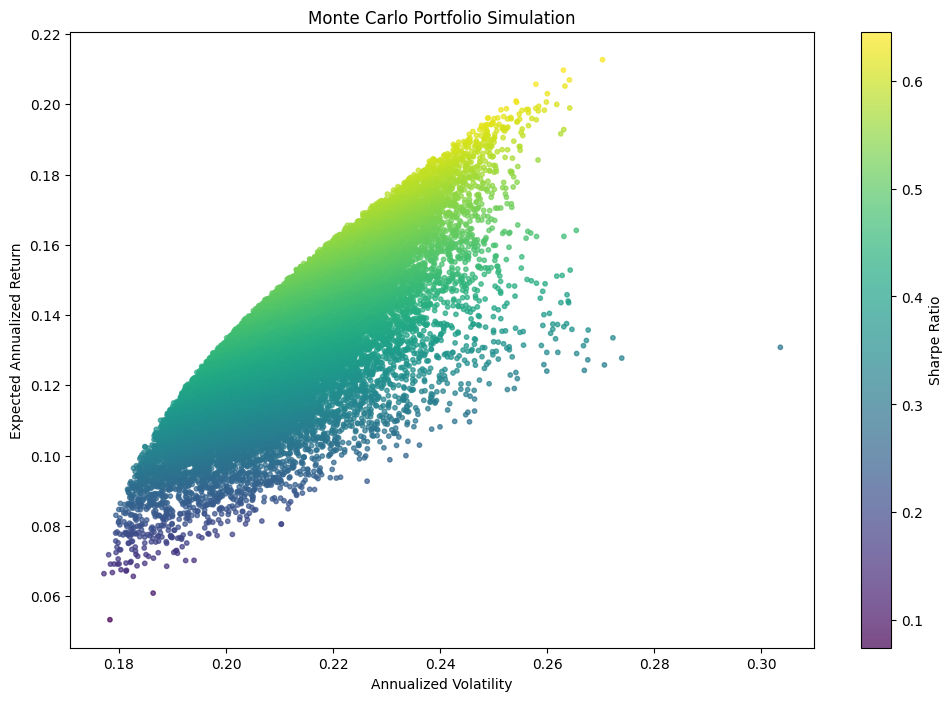

In [81]:
plt.figure(figsize=(12,8))

plt.scatter(simulation_results['Volatility'],
    simulation_results['Return'],
    c=simulation_results['Sharpe Ratio'],
    cmap='viridis',
    alpha=0.7,
    s=10)

plt.colorbar(label='Sharpe Ratio')

plt.title('Monte Carlo Portfolio Simulation')

plt.xlabel('Annualized Volatility')

plt.ylabel('Expected Annualized Return')

plt.show()


**Remark:** The scatterplot illustrates the risk-return profile of each random portfolio generated by the previous simulations. The closer to the upper-left boundary a portfolio lies, the more efficient it is, since such portfolios offer higher returns with lower volatility.

We now identify the portfolio with the maximum Sharpe ratio and the portfolio with the minimum volatility.

In [91]:
max_sharpe_index = simulation_results['Sharpe Ratio'].idxmax()
max_sharpe_ratio_portfolio = simulation_results.iloc[max_sharpe_index]
max_sharpe_ratio_portfolio_weights = portfolio_weights[max_sharpe_index]

min_volatility_index = simulation_results['Volatility'].idxmin()
min_volatility_portfolio = simulation_results.iloc[min_volatility_index]
min_volatility_portfolio_weights = portfolio_weights[min_volatility_index]

In [98]:
print('Max Sharpe ratio portfolio weights:')
for stock in range(len(stocks)):
        print(f'{stocks[stock]:<4} : {round(max_sharpe_ratio_portfolio_weights[stock] * 100, 2)}%')

print('')
print('Max Sharpe ratio portoflio features:')
print(max_sharpe_ratio_portfolio, '\n')

print('------------------------------------', '\n')


print('Min Volatility portfolio weights:')
for stock in range(len(stocks)):
        print(f'{stocks[stock]:<4} : {round(min_volatility_portfolio_weights[stock] * 100, 2)}%')

print('')
print('Min Volatility portoflio features:')
print(min_volatility_portfolio)


Max Sharpe ratio portfolio weights:
AAPL : 61.66%
MSFT : 0.37%
JNJ  : 12.28%
JPM  : 0.39%
KO   : 9.49%
XOM  : 15.81%

Max Sharpe ratio portoflio features:
Return          0.209746
Volatility      0.263017
Sharpe Ratio    0.645382
Name: 17992, dtype: float64 

------------------------------------ 

Min Volatility portfolio weights:
AAPL : 3.68%
MSFT : 46.55%
JNJ  : 1.77%
JPM  : 32.87%
KO   : 6.29%
XOM  : 8.84%

Min Volatility portoflio features:
Return          0.066392
Volatility      0.177216
Sharpe Ratio    0.148927
Name: 15241, dtype: float64


We highlight these two portfolios on the previous graph.

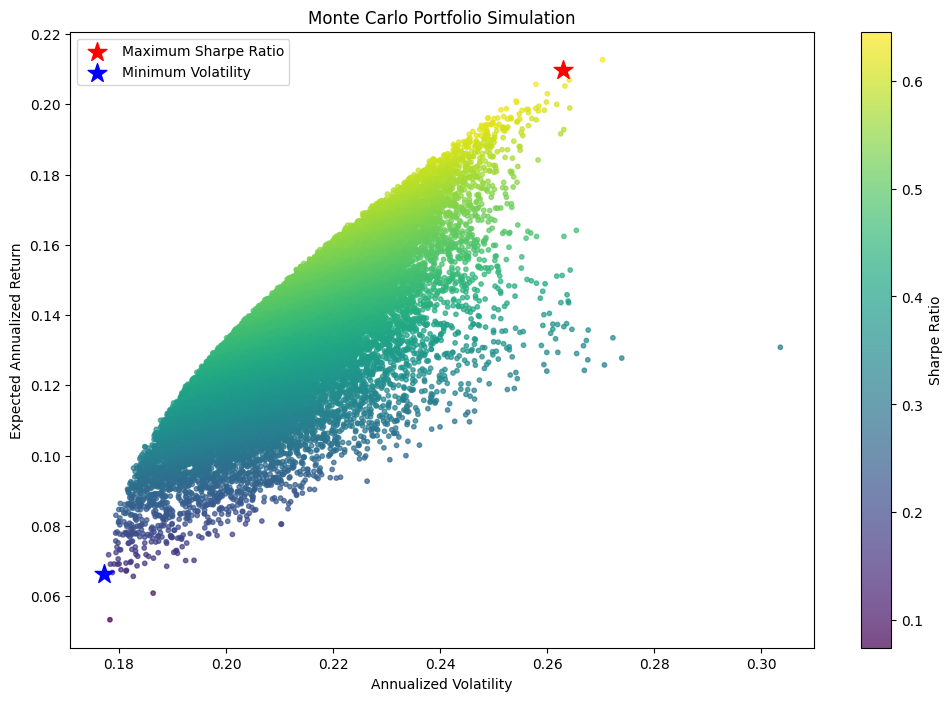

In [99]:
plt.figure(figsize=(12,8))

plt.scatter(
    simulation_results['Volatility'],
    simulation_results['Return'],
    c=simulation_results['Sharpe Ratio'],
    cmap='viridis',
    alpha=0.7,
    s=10)

plt.colorbar(label='Sharpe Ratio')

plt.scatter(
    max_sharpe_ratio_portfolio['Volatility'],
    max_sharpe_ratio_portfolio['Return'],
    color='red',
    marker='*',
    s=200,
    label='Maximum Sharpe Ratio')

plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    color='blue',
    marker='*',
    s=200,
    label='Minimum Volatility')

plt.title('Monte Carlo Portfolio Simulation')

plt.xlabel('Annualized Volatility')

plt.ylabel('Expected Annualized Return')

plt.legend()

plt.show()

**Remark:** As we already mentioned, the upper-left boundary of the above set of portfolios is of particular importance and is commonly referred to as the Efficient Frontier. More specifically, each point lying on the frontier yields the highest possible return for a given level of risk.

To obtain a descrete approximation of the Efficient Frontier numerically, we group portfolios with similar risk levels and, within each group, select the portfolio with the highest expected return.

In [ ]:
simulation_results['Volatility Bin'] = pd.cut(simulation_results['Volatility'], bins=100)

efficient_portfolios = (
    simulation_results
    .sort_values('Return', ascending=False)
    .groupby('Volatility Bin')
    .head(1)
    .sort_values('Volatility'))

efficient_portfolios.head()

,Return,Volatility,Sharpe Ratio,Volatility Bin
12622,0.071788,0.178087,0.178499,"(0.177, 0.178]"
13994,0.083020,0.179450,0.239735,"(0.178, 0.18]"
24697,0.086401,0.180279,0.257386,"(0.18, 0.181]"
28356,0.092582,0.182246,0.288521,"(0.181, 0.182]"
1390,0.097117,0.183254,0.311685,"(0.182, 0.184]"


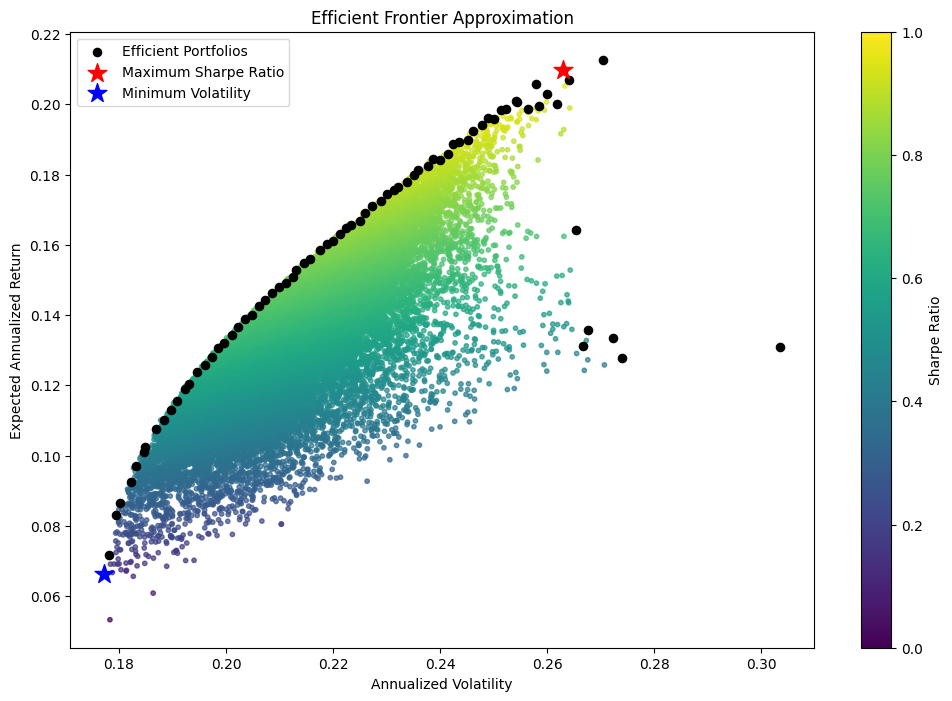

In [115]:
plt.figure(figsize=(12,8))

plt.scatter(
    simulation_results['Volatility'],
    simulation_results['Return'],
    c=simulation_results['Sharpe Ratio'],
    cmap='viridis',
    alpha=0.7,
    s=10
)

plt.scatter(
    efficient_portfolios['Volatility'],
    efficient_portfolios['Return'],
    color='black',
    s=35,
    label='Efficient Portfolios'
)

plt.scatter(
    max_sharpe_ratio_portfolio['Volatility'],
    max_sharpe_ratio_portfolio['Return'],
    color='red',
    marker='*',
    s=200,
    label='Maximum Sharpe Ratio'
)

plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    color='blue',
    marker='*',
    s=200,
    label='Minimum Volatility'
)

plt.xlabel('Annualized Volatility')

plt.ylabel('Expected Annualized Return')

plt.title('Efficient Frontier Approximation')

plt.colorbar(label='Sharpe Ratio')

plt.legend()

plt.show()

**Remark:** The set of black points represents a discete approximation of the Efficient Frontier.

## 10. CAPM and Beta Analysis

Each equity's total risk consists of two types of risk: idiosyncratic risk and systematic risk.

The first is associated with firm-specific characteristics, such as company performance, revenue, management decisions, production costs, and other internal factors. Consequently, idiosyncratic risk mainly affects individual assets or specific sectors and can be substantially reduced through diversification.

On the other hand, systematic risk is associated with broader market conditions and macroeconomic factors, such as inflation, interest rates, economic recessions, or geopolitical events. Since these factors affect the entire market, systematic risk cannot be eliminated through diversification.

So far, we have examined portfolio risk and return mainly from the perspective of diversification and asset-specific interactions.

Although market-wide effects were already implicitly present in quantities such as volatility, covariance, and Sharpe ratio, we now investigate systematic risk explicitly and study how asset returns relate to overall market movements.